# Fraud detection - seminar work

In [3]:
%reset

In [4]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn: data splitting, models, metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    recall_score, precision_score, f1_score,
    roc_auc_score, confusion_matrix
)

# XGBoost
from xgboost import XGBClassifier

# Model interpretability
import shap

In [5]:
data = pd.read_csv("fraud_oracle.csv")

## Simple EDA before feature enginnering

In [6]:
print("Visual data check:")
display(data.head(10))
print(f"\nNumber of rows: {data.shape[0]}, number of columns: {data.shape[1]}")
print("\nAvailable columns:")
print(list(data.columns))

Visual data check:


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision
5,Oct,4,Friday,Honda,Urban,Wednesday,Nov,1,Male,Single,...,5 years,21 to 25,No,No,External,3 to 5,no change,1 vehicle,1994,Collision
6,Feb,1,Saturday,Honda,Urban,Monday,Feb,3,Male,Married,...,7 years,36 to 40,No,No,External,1 to 2,no change,1 vehicle,1994,Collision
7,Nov,1,Friday,Honda,Urban,Tuesday,Mar,4,Male,Single,...,new,16 to 17,No,No,External,none,no change,1 vehicle,1994,Collision
8,Dec,4,Saturday,Honda,Urban,Wednesday,Dec,5,Male,Single,...,6 years,31 to 35,No,Yes,External,3 to 5,no change,1 vehicle,1994,Collision
9,Apr,3,Tuesday,Ford,Urban,Wednesday,Apr,3,Male,Married,...,more than 7,36 to 40,No,No,External,3 to 5,no change,1 vehicle,1994,All Perils



Number of rows: 15420, number of columns: 33

Available columns:
['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']


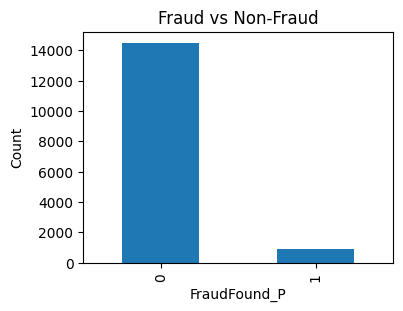

              Absolute  Relative
FraudFound_P                    
0                14497      94.0
1                  923       6.0


In [7]:
counts = data['FraudFound_P'].value_counts()
percents = (counts / counts.sum() * 100).round(1)

plt.figure(figsize=(4,3))
counts.plot(kind='bar')
plt.title("Fraud vs Non-Fraud")
plt.xlabel("FraudFound_P")
plt.ylabel("Count")
plt.show()

print(pd.DataFrame({'Absolute': counts, 'Relative': percents}))

In [8]:
print("Quick look at numeric features:")
data[['Age', 'Deductible', 'DriverRating']].describe()

Quick look at numeric features:


,Age,Deductible,DriverRating
count,15420.000000,15420.000000,15420.000000
mean,39.855707,407.704280,2.487808
std,13.492377,43.950998,1.119453
min,0.000000,300.000000,1.000000
25%,31.000000,400.000000,1.000000
50%,38.000000,400.000000,2.000000
75%,48.000000,400.000000,3.000000
max,80.000000,700.000000,4.000000


In [9]:
print("Fraud rate by a few important raw features:")
cols = [
    'AccidentArea',
    'VehicleCategory',
    'PoliceReportFiled',
    'AgentType',
    'PastNumberOfClaims'
]

for col in cols:
    print("\n=== {} ===".format(col))
    print(data.groupby(col)['FraudFound_P'].mean())

Fraud rate by a few important raw features:

=== AccidentArea ===
AccidentArea
Rural    0.083229
Urban    0.057155
Name: FraudFound_P, dtype: float64

=== VehicleCategory ===
VehicleCategory
Sedan      0.082205
Sport      0.015677
Utility    0.112532
Name: FraudFound_P, dtype: float64

=== PoliceReportFiled ===
PoliceReportFiled
No     0.060499
Yes    0.037383
Name: FraudFound_P, dtype: float64

=== AgentType ===
AgentType
External    0.060544
Internal    0.016598
Name: FraudFound_P, dtype: float64

=== PastNumberOfClaims ===
PastNumberOfClaims
1              0.062133
2 to 4         0.053601
more than 4    0.033831
none           0.077895
Name: FraudFound_P, dtype: float64


## Feature engineering brainstorming

In [10]:
# Drop: PolicyNumber, Days_Policy_Accident, Days_Policy_Claim, RepNumber, AgeOfPolicyHolder
# Divide column: PolicyType -> VehicleCategory (overwrite) use only that
# Onehot encoding: sex, marital status, fault, PoliceReportFiled, WitnessPresent, AgentType, AccidentArea
# Feature: days between incident and claim; Turn make into first 10 as is, other as "other"
# Categorical bins: VehiclePrice, Days_Policy_Claim, PastNumberOfClaims, AgeOfVehicle, NumberOfSuppliments, AddressChange_Claim, NumberOfCars
# Bins: age, Deductible
# Target: FraudFound_P

## Drop obvious useless columns

In [11]:
# Drop: PolicyNumber, Days_Policy_Accident, Days_Policy_Claim, RepNumber, AgeOfPolicyHolder
df = data.drop(columns=['PolicyNumber', 'Days_Policy_Accident', 'Days_Policy_Claim', 'RepNumber', 'AgeOfPolicyHolder'])

In [12]:
# Divide column: PolicyType -> VehicleCategory (overwrite) use only that
df = df.drop(columns=['VehicleCategory'])
df['PolicyType'] = df['PolicyType'].str.split(" - ").str[0]

In [13]:
df.Make.value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Dodge         109
Saab          108
Mercury        83
Saturn         58
Nisson         30
BMW            15
Jaguar          6
Porche          5
Mecedes         4
Ferrari         2
Lexus           1
Name: count, dtype: int64

In [14]:
# Find top 10 most common makes
top_10_makes = df['Make'].value_counts().index[:10]

# Replace all other makes with "Other"
df['Make'] = df['Make'].where(df['Make'].isin(top_10_makes), other='Other')


In [15]:
df.Make.value_counts()

Make
Pontiac      3837
Toyota       3121
Honda        2801
Mazda        2354
Chevrolet    1681
Accura        472
Ford          450
VW            283
Other         204
Dodge         109
Saab          108
Name: count, dtype: int64

In [16]:
# Claim delay feature = weeks between incident and claim
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['IncMonthNum']   = df['Month'].map(month_map)
df['ClaimMonthNum'] = df['MonthClaimed'].map(month_map)

# Simple “week index” = Year * 12*4 + Month * 4 + WeekOfMonth
incident_week = (df['Year'] * 48 +
                 df['IncMonthNum'] * 4 +
                 df['WeekOfMonth'])

claim_week = (df['Year'] * 48 +
              df['ClaimMonthNum'] * 4 +
              df['WeekOfMonthClaimed'])

df['WeeksIncidentToClaim'] = (claim_week - incident_week)

# Drop detailed date columns (we keep only the delay)
df = df.drop(columns=[
    'Month', 'MonthClaimed', 'DayOfWeek', 'DayOfWeekClaimed',
    'WeekOfMonth', 'WeekOfMonthClaimed',
    'IncMonthNum', 'ClaimMonthNum'
])

## Bins

In [17]:
age_bins = pd.qcut(df['Age'], q=5, duplicates='drop')
df['Age'] = age_bins.cat.codes.astype('int64')
age_labels = [f"Age_{i}" for i in range(len(age_bins.cat.categories))]
df['Age'] = age_bins.cat.rename_categories(age_labels)

In [18]:
df['Deductible'] = pd.cut(
    df['Deductible'],
    bins=[0, 350, 450, 1000],
    labels=['Low', 'Medium', 'High'],
    right=False
)
df['Deductible'].value_counts()

Deductible
Medium    14838
High        574
Low           8
Name: count, dtype: int64

## Onehot encoding categorical

In [19]:
# Onehot encoding: sex, maritial status, fault, PoliceReportFiled, WitnessPresent, AgentType, 'PolicyType', 'BasePolicy'

cols_to_encode = [
    'Sex',
    'MaritalStatus',
    'Fault',
    'PoliceReportFiled',
    'WitnessPresent',
    'AgentType',
    'AccidentArea',
    'PolicyType',
    'BasePolicy'
]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

# Categorical bins: VehiclePrice, PastNumberOfClaims, AgeOfVehicle, NumberOfSuppliments, AddressChange_Claim, NumberOfCars
cols_to_encode = [
    'VehiclePrice',
    'PastNumberOfClaims',
    'AgeOfVehicle',
    'NumberOfSuppliments',
    'AddressChange_Claim',
    'NumberOfCars',
]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

cols_to_encode = [
    'Age', 'Deductible', 'Make'
]

df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

## Models

In [20]:
df = df.copy()
df = df.dropna()
y = df['FraudFound_P'].astype(int)
X = df.drop(columns=['FraudFound_P'])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

pos = y_train.sum()
neg = len(y_train) - pos
scale_pos_weight = neg / pos

lr = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    n_jobs=-1
)

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [37]:
def find_threshold_with_workload(y_true, y_proba, max_positive_rate=0.25):
    """
    Search for the highest recall under a maximum positive rate constraint.
    max_positive_rate ~ "workload" (share of cases flagged for review).
    """
    thresholds = np.linspace(0.01, 0.99, 99)
    best_thr = 0.5
    best_recall = -1.0

    for thr in thresholds:
        y_pred = (y_proba >= thr).astype(int)
        pos_rate = y_pred.mean()
        if pos_rate > max_positive_rate:
            continue
        rec = recall_score(y_true, y_pred)
        if rec > best_recall:
            best_recall = rec
            best_thr = thr

    return best_thr, best_recall

In [42]:
# List of models to evaluate (name, model_object)
models_list = [
    ("LogReg", lr),
    ("RF", rf),
    ("XGB", xgb),
]

rows = []

for name, model in models_list:
    # Predicted probabilities on validation and test sets
    # (positive class = fraud)
    p_valid = model.predict_proba(X_valid)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    for w in workloads:
        # Find the threshold that satisfies a given maximum positive rate
        # (workload constraint) while maximizing recall on the VALIDATION set
        thr, _ = find_threshold_with_workload(
            y_valid,
            p_valid,
            max_positive_rate=w
        )

        # Apply the selected threshold on the TEST set
        y_pred = (p_test >= thr).astype(int)

        # Confusion matrix on the TEST set
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        # Test-set classification metrics
        recall_t = recall_score(y_test, y_pred)
        precision_t = precision_score(y_test, y_pred)
        f1_t = f1_score(y_test, y_pred)
        auc_t = roc_auc_score(y_test, p_test)
        pos_rate_t = y_pred.mean()   # actual workload on TEST

        # Append one row for the current (model, workload) combination
        rows.append({
            "model": name,
            "max_pos_rate_req": w,         # required workload on VALID
            "threshold": round(thr, 2),    # selected threshold
            "recall_test": recall_t,
            "precision_test": precision_t,
            "f1_test": f1_t,
            "auc_test": auc_t,
            "positive_rate_test": pos_rate_t,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

results_df = pd.DataFrame(rows)
results_df


,model,max_pos_rate_req,threshold,recall_test,precision_test,f1_test,auc_test,positive_rate_test,TP,FP,FN,TN
0,LogReg,0.20,0.69,0.467391,0.154955,0.232747,0.797282,0.179961,86,469,98,2431
1,LogReg,0.25,0.65,0.597826,0.143979,0.232068,0.797282,0.247730,110,654,74,2246
2,LogReg,0.30,0.62,0.663043,0.136618,0.226555,0.797282,0.289559,122,771,62,2129
3,RF,0.20,0.28,0.478261,0.152249,0.230971,0.800316,0.187419,88,490,96,2410
4,RF,0.25,0.25,0.581522,0.145777,0.233115,0.800316,0.238003,107,627,77,2273
5,RF,0.30,0.22,0.684783,0.139535,0.231831,0.800316,0.292802,126,777,58,2123
6,XGB,0.20,0.61,0.494565,0.155290,0.236364,0.802675,0.190013,91,495,93,2405
7,XGB,0.25,0.54,0.625000,0.145939,0.236626,0.802675,0.255512,115,673,69,2227
8,XGB,0.30,0.48,0.679348,0.137061,0.228102,0.802675,0.295720,125,787,59,2113


Chosen threshold (workload ~25%): 0.54
Confusion matrix @ 25% workload threshold: [[2227  673]
 [  69  115]]


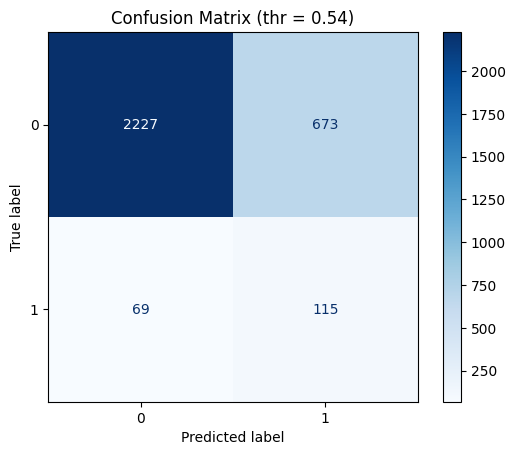

recall: 0.625
precision: 0.14593908629441624
f1: 0.2366255144032922
auc: 0.8026752248875563
positive_rate: 0.25551232166018156


In [43]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

# 4) Find threshold on VALID for workload ≈ 25 %
p_valid = xgb.predict_proba(X_valid)[:, 1]
thr_25, rec_25 = find_threshold_with_workload(
    y_valid, p_valid, max_positive_rate=0.25
)
print("Chosen threshold (workload ~25%):", thr_25)

# 5) Evaluate on TEST using this threshold
p_test = xgb.predict_proba(X_test)[:, 1]
y_pred = (p_test >= thr_25).astype(int)

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix @ 25% workload threshold:", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix (thr = {thr_25:.2f})")
plt.show()

print("recall:", recall_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print("auc:", roc_auc_score(y_test, p_test))
print("positive_rate:", y_pred.mean())

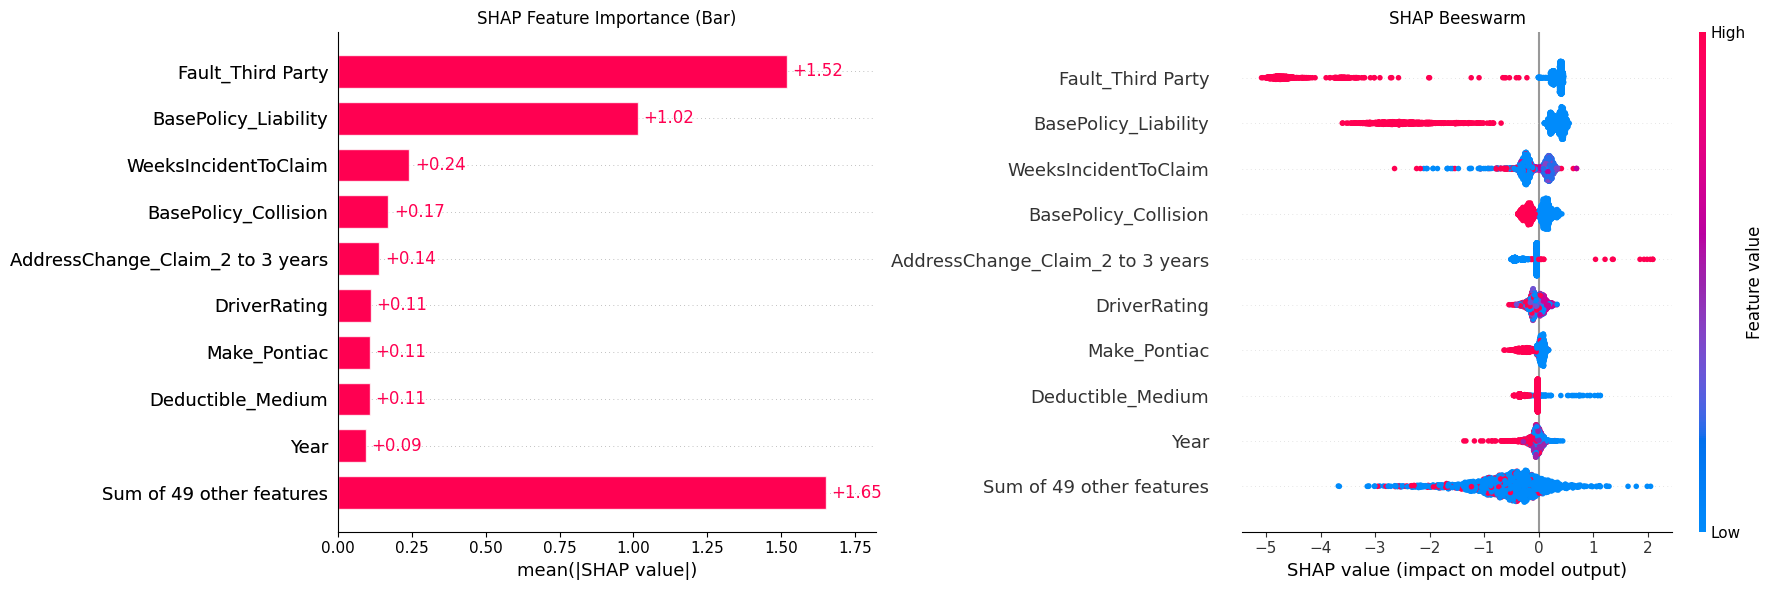

In [44]:
# choose data for SHAP
# use the train+valid data you used to fit xgb_final
# (sample if it's large to keep SHAP fast)
X_shap = X_tv.sample(
    n=min(2000, len(X_tv)),
    random_state=42
)

#  compute SHAP values
explainer = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_shap)

# plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# left: global feature importance (bar)
shap.plots.bar(
    shap_values,
    ax=axes[0],
    show=False
)
axes[0].set_title("SHAP Feature Importance (Bar)")

# right: distribution per feature (beeswarm)
shap.plots.beeswarm(
    shap_values,
    ax=axes[1],
    show=False,
    plot_size=None
)
axes[1].set_title("SHAP Beeswarm")

plt.tight_layout()
plt.show()

### Interpretation of Red Flags

- The most significant predictors of fraud are: `Fault_Third Party`, `BasePolicy_Liability`, and `WeeksIncidentToClaim`.

- The model strongly reacts to reporting delays, the type of insurance policy, and the circumstances of the accident.

- Some demographic and historical signals are also important, such as a recent change of address.

- Overall, the SHAP analysis confirms that the model is not making random decisions — it relies on consistent and business-interpretable patterns.



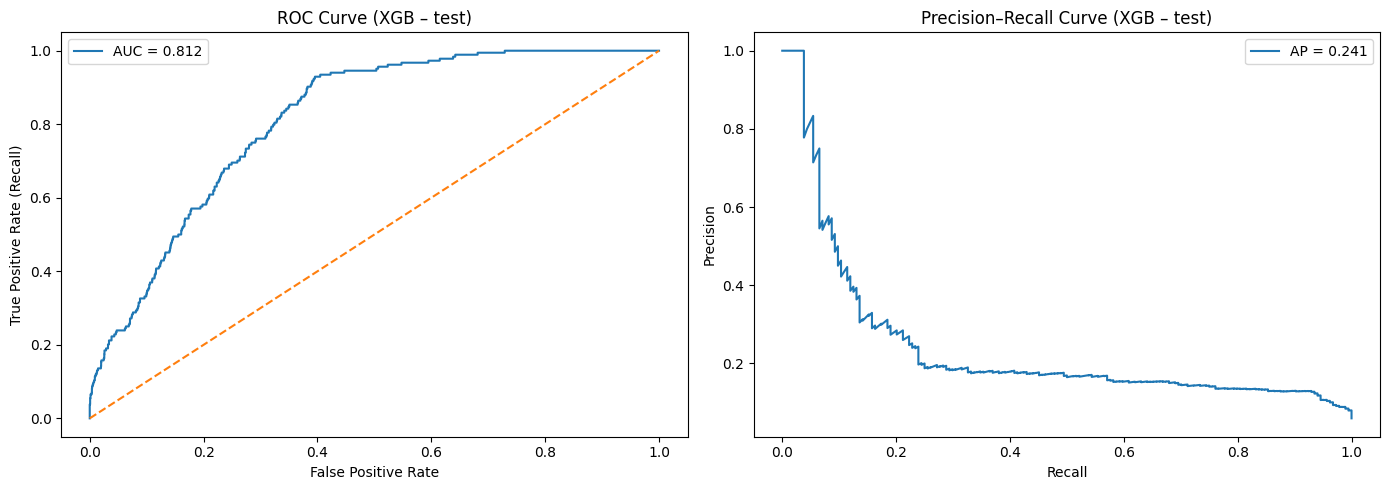

In [45]:
# choose data for evaluation
X_eval = X_test
y_eval = y_test

# predicted probabilities for positive class
y_proba = xgb_final.predict_proba(X_eval)[:, 1]

# ROC curve
fpr, tpr, roc_thr = roc_curve(y_eval, y_proba)
roc_auc = roc_auc_score(y_eval, y_proba)

# Precision–Recall curve
precision, recall, pr_thr = precision_recall_curve(y_eval, y_proba)
pr_auc = average_precision_score(y_eval, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve (XGB – test)")
axes[0].legend()

# PR
axes[1].plot(recall, precision, label=f"AP = {pr_auc:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision–Recall Curve (XGB – test)")
axes[1].legend()

plt.tight_layout()
plt.show()

### **ROC Curve (AUC = 0.812)**
The model achieves an AUC of **0.812**, showing solid discriminatory ability between fraudulent and legitimate claims. The curve is far above the diagonal baseline, indicating that the model is significantly better than random guessing. An AUC around 0.8 is generally considered good performance for fraud detection tasks.

### **Precision–Recall Curve (AP = 0.241)**
The average precision of **0.241** is typical for heavily imbalanced fraud datasets. Precision remains low across most recall range — which reflects the reality of the task: catching more frauds necessarily leads to reviewing many non-fraud claims. The PR curve clearly demonstrates why a fixed workload cap is required.

### Conclusion
The model performs well overall: strong ROC performance, realistic precision, and clear trade-offs shown in PR space. The chosen operating point (**25% workload**, **threshold 0.54**) is justified: it allows capturing a significant portion of fraud cases while keeping the manual review capacity within limits.
